# Tarefa 3 - Neural Networks Coursework 2026

Third assessed coursework for **Tecnicas e Algoritmos em Ciencia de Dados**.

Write your 6-digit anonymous identifier in the first code cell. Submit a single notebook named with that identifier, for example `568423.ipynb`. Do not submit datasets or extra Python scripts. Any helper function used by your solution must be included in this notebook.

This notebook is a guide. The TODO cells mark the parts you must implement. The TensorFlow baseline cells are provided so you can compare your own implementations against a standard neural-network baseline.

## Overview

1. Regression with neural networks (50%)
2. Multiclass classification with neural networks (50%)

## General rules

- You may use NumPy and basic libraries for matrix operations.
- You must not use library implementations for the algorithms you are asked to implement manually.
- Standardize features manually using only training-set statistics.
- Use the validation set for model selection.
- Use the test set only for final reporting.
- Restart the kernel and run the full notebook before submitting.


In [1]:
student_id = "810597" # Replace with your 6-digit anonymous identifier.
student_id


'810597'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, f1_score, accuracy_score

np.random.seed(0)


In [3]:
# Versions
print(f"SNS: {sns.__version__}")
print(f"PD: {pd.__version__}")
print(f"NP: {np.__version__}")

SNS: 0.13.2
PD: 3.0.1
NP: 2.4.2


versões das bibliotecas de marcelo

SNS: 0.13.2 <br>
PD: 3.0.1 <br>
NP: 2.4.2 <br>

# Helper Functions

Implement any shared helper functions here. In particular, you will need a function to standardize validation and test data using the mean and standard deviation computed from the training set.

Do not use `sklearn.preprocessing.StandardScaler` for this coursework requirement.


In [103]:
def standardize_from_train(X_train, X_val, X_test):
    """Standardize X_train, X_val, and X_test using training-set statistics only."""
    # TODO:
    # 1. Compute the mean of each feature using X_train.
    mu = np.mean(X_train, axis=0)

    # 2. Compute the standard deviation of each feature using X_train.
    sigma = np.std(X_train,axis=0)

    # 3. Replace any zero standard deviation with 1.0.
    sigma = np.where(sigma == 0, 1.0, sigma)

    # 4. Transform X_train, X_val, and X_test with the training mean/std.
    X_train_scaled = (X_train - mu) / sigma
    X_val_scaled = (X_val - mu) / sigma
    X_test_scaled = (X_test - mu) / sigma

    # 5. Return the three transformed arrays, plus the mean and std if useful.
    return X_train_scaled, X_val_scaled, X_test_scaled, mu, sigma


def rmse(y_true: np.ndarray, y_pred: np.ndarray):
    """Return the root mean squared error."""
    # TODO: implement RMSE with NumPy.
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1) 

    return np.sqrt(np.mean((y_pred - y_true)**2))


def multiclass_metrics(y_true_one_hot, predicted_probabilities, predicted_labels):
    """Compute AUROC, precision, F1, and accuracy for multiclass predictions."""
    # TODO: use sklearn metric functions for reporting only.
    # Hint: AUROC should use probabilities. Precision/F1/accuracy use predicted labels.

    y_true_labels = np.argmax(y_true_one_hot, axis=1)

    auroc = roc_auc_score(
        y_true_one_hot, predicted_probabilities, multi_class="ovr"
    )

    precision = precision_score(
        y_true_labels, predicted_labels, average="macro"
    )

    f1 = f1_score(
        y_true_labels, predicted_labels, average="macro"
    )

    accuracy = accuracy_score(
        y_true_labels, predicted_labels
    )

    return auroc, precision, f1, accuracy


# Part 1 - Regression With Neural Networks (50%)

## Dataset

Use `student_performance.csv`. Each row corresponds to a student. The target is `final_score`.

Required preprocessing:

1. Load the dataset.
2. Data cleaning, droping duplicates, and convert categorical variables to numerical variables.
3. Use `final_score` as the regression target.
4. Do not use `student_id` as a feature.
5. Do not use `passed` as a feature because it is derived from the final score.
6. Split the data into training, validation, and test sets using a 70:15:15 ratio.
7. Standardize features manually using only training-set statistics.


In [17]:
performance = pd.read_csv("student_performance.csv")
display(performance.head())
display(performance.describe(include="all"))

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


In [69]:
# TODO: Regression preprocessing.
# - Convert categorical variables to numerical variables.
pf = performance.drop(columns=["student_id", "passed"]).drop_duplicates()

pf["gender"] = pf["gender"].map({"Male":1, "Female":0})
pf["internet_access"] = pf["internet_access"].map({"Yes":1, "No":0})
pf["extracurricular"] = pf["extracurricular"].map({"Yes":1, "No":0})

pf["parent_education"] = pf["parent_education"].fillna("Other")
pf = pd.get_dummies(
    pf,
    columns=["parent_education"],
    prefix="edu",
    dtype=int
)

# - Set y to the final_score column.
y = pf["final_score"].values

# - Set X to the feature matrix after dropping student_id, final_score, and passed.
X = pf.drop(columns=["final_score"])


# Example variable names expected by later cells:
# X = ...
# y = ...



In [19]:
# TODO: Split into train/validation/test using a 70:15:15 ratio.
# Hint: first split off 30% as temporary data, then split that temporary data in half.

X_train, X_aux, y_train, y_aux = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X, y, test_size=0.5)

X_train, X_val, X_test, mu, sigma = standardize_from_train(X_train, X_val, X_test)

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test



## NumPy Regression Neural Network

Implement a fully connected neural network using NumPy.

Requirements:

- The number of hidden layers must be configurable.
- Every hidden layer must have the same number of neurons.
- Use sigmoid activation functions in hidden layers.
- Use a linear output layer.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support three update methods: batch gradient descent, stochastic gradient descent, and mini-batch gradient descent.
- Use early stopping to prevent overfitting.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `50` epochs.


In [101]:
# If you want to implement without using POO, you can implement the following functions instead of the NeuralNetworkRegression class.
# My recommended approach is to implement the class, but you can implement the following functions if you prefer a functional programming style.
class NeuralNetworkRegression:
    
    def __init__(self, input_size: int, hidden_layers:int, neurons_per_layer:int, output_size:int=1):
        # TODO: initialize weights and biases for a variable number of layers.
        """Inicialização dos pesos e bias de toda a rede neural

        Args:
            input_size (int): dimensão dos nossos dados de entrada
            hidden_layers (int): numero de hidden layers
            neurons_per_layer (int): dimensão das hidden layers
            output_size (int, optional): dimensão dos dados de saida. Defaults to 1.
        """

        self.input_size = input_size
        self.hidden_layers = hidden_layers
        self.neurons_per_layer = neurons_per_layer
        self.output_size = output_size

        # Mapeira a dimensão de cada camada da rede
        self.layers_structure = [input_size] + [neurons_per_layer] * hidden_layers + [output_size]

        # Lista com cada matriz W depesos usando o bias trick
        self.weight = []

        # Subtraimos 1 pois se temos K camada ao total então precisamos apenas de K - 1 transformações
        for L in range(len(self.layers_structure) - 1): 

            # Como usamos a notação TO-FROM cada uma das nossas
            # W^{(L+1)} tera shape (L+1, L) <-> (dim(out), dim(in)) 
            dim_out = self.layers_structure[L+1]

            # Bias Trick: Aumentamos em 1 a dimensão da camada de entrada para acomodar o vies 
            dim_in = self.layers_structure[L] + 1

            # Usamos a inicialização de Xavier
            std = np.sqrt(2/ (dim_in + dim_out))

            WL = np.random.randn(dim_out, dim_in) * std

            self.weight.append(WL)

    def sigmoid(self, a):
        return 1.0 / (1.0 + np.exp(-np.clip(a, -500, 500)))

    def forward(self, X:np.ndarray):
        # TODO: implement the forward pass.
        """Realização do foward pass na rede neural com função de ativação sigmoide nas hidden layers

        Args:
            X (np.ndarray): Matriz de dados (sem bias), cada linha representa uma instancia

        Return:
            Z (np.ndarray): Predições
            ativacoes (np.ndarray): Matrizes ativadas de cada camada, iniciando pela input layer finalizando na output layer
        """
        # Aqui guardaremos todas as matrizes Z ativadas
        ativacoes = [X]
        num_transformacoes = len(self.weight)

        # A primeira camada por definição ja esta ativada
        Z = X

        # Para cada matriz de pessos W faremos uma ativação
        for L in range(num_transformacoes):
            # como usamos o Bias Trick devemos adicionar uma coluna de 1s na matriz de dados atual
            ones = np.ones((Z.shape[0], 1))
            Z_bb = np.c_[Z, ones]

            # devemos transpor a matriz W de pesos pois estamos usando a notação TO-FROM
            # na notação TO-FROM cada linha representa um neuronio da camada atual L
            # cada coluna representa um neuronio da camada anterior.
            # Uma matriz W da camada atual é aquela que transforma os dados Z^{L-1} para A^{L-1} 

            A = Z_bb.dot(self.weight[L].T) # Dados transformados

            if L < num_transformacoes - 1: # Ou seja se estamos antes da ultima transformação
                Z = self.sigmoid(A)
            else: # Se estamos na ultima camada não fazemos nada
                Z = A

            ativacoes.append(Z)

        return Z, ativacoes

    def backward(self, activations: np.ndarray, y_true: np.ndarray):
        """Implementação do backpropagation, ele apenas calcula o gradiente de cada matriz de pesos W

        Args:
            activations (np.ndarray): Matrizes Z ativadas de cada camada da rede neural sem bias na ordem: [X, Z_1, Z_2, ..., Z_out]
            y_true (np.ndarray): Target, saida final esperada
        """
        # TODO: implement backpropagation.
        if y_true.ndim == 1:
            y_true = y_true.reshape(-1, 1)

        num_transformacoes = len(self.weight)
        N = y_true.shape[0] # Numero de instancias

        # Lista para armazenar o gradiente de cada matriz W
        gradients = [np.zeros_like(W) for W in self.weight]

        # Calculamos Delta da Output Layer, não precisamos de nenhuma tranformação W
        delta = activations[-1] - y_true

        # Então iteramos de traz pra frente, desde a ultima camada ate a primeira
        # [X, Z_1, Z_2, ..., Z_out]

        # se temos 20 camadas então teremos 19 transformações logo os inidices serão = 18, 17, .., 1, 0
        for L in reversed(range(num_transformacoes)):
            
            # activations[L] (fisico) é Z^{L} (logico) pois activations começa com os dados de entrada X
            # self.weight[L] (fisico) é W^{L+1} (logico) pois weights inicia com W^{1} #weights = num_camadas - 1
            # Logo Z_in é a matriz de dados (sem bias) que usamos para gerar a camada L+1

            Z_in =  activations[L]

            # Precisamos então adicioanar o bias em Z_in
            ones = np.ones((Z_in.shape[0], 1))
            Z_in_bb = np.c_[Z_in, ones]

            # Calculamos o gradiente do W atual
            gradients[L] = (delta.T).dot(Z_in_bb) / N

            # Calculamos o delta da camada anterior D^{L-1} = D^{L}W^{L} * Z^{L-1} * (1 - Z^{L-1})
            # Neste caso o Z^{L-1} teorico aqui é dado por activations[L].
            if L > 0:
                W_nb = self.weight[L][:,:-1]
                delta = delta.dot(W_nb) * (activations[L] * (1 - activations[L]))

        return gradients
    

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=50,
        learning_rate=0.01,
        update_method="mini_batch",
        batch_size=32,
        patience=10,
    ):
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        # TODO: return training and validation loss histories.

        N = X_train.shape[0] # numero de instancias
        training_loss = []
        validation_loss = []
        patience_count = 0
        best_val_err = float("inf")
        best_weights = [W.copy() for W in self.weight]

        match update_method:
            case "batch":
                for each_epoch in range(epochs):
                    # Fazer o Forward pass no conjunto inteiro (batch) para calcular as ativacoes
                    y_train_pred, activations = self.forward(X_train)
                    y_val_pred, _ = self.forward(X_val)

                    # Calcular o Erro no conjunto de validação e de treino para guardar a historia
                    train_err = rmse(y_train, y_train_pred)
                    val_err = rmse(y_val, y_val_pred)

                    training_loss.append(train_err)
                    validation_loss.append(val_err)

                    if val_err < best_val_err:
                        best_val_err = val_err
                        patience_count = 0
                        best_val_err = val_err
                        best_epoch = each_epoch

                        # salvamos os melhores pesos
                        best_weights = [W.copy() for W in self.weight]
                    else:
                        patience_count += 1

                    if patience_count >= patience:
                        break

                    # Fazer o Backward para calcular os gradientes
                    gradients = self.backward(activations, y_train)

                    # Depois substituir os pesos W
                    for L in range(len(self.weight)):
                        self.weight[L] -= learning_rate * gradients[L]
                        

                self.weight = best_weights

                return training_loss, validation_loss, each_epoch, best_epoch
            
            case "sgd":
                for each_epoch in range(epochs):
                    # Fazer o mesmo passo a passo anterior porem para cada entrada de dados i
                    for i in range(N):
                        X_i = X_train[i:i+1] # dessa forma X_i ainda é uma matriz de uma linha
                        y_i = y_train[i:i+1]

                        # Fazer o Forward pass para calcular as ativacoes
                        _, activations = self.forward(X_i)


                        # Fazer o Backward para calcular os gradientes
                        gradients = self.backward(activations, y_i)

                        # Depois substituir os pesos W
                        for L in range(len(self.weight)):
                            self.weight[L] -= learning_rate * gradients[L]

                    # Calcular o Erro no conjunto de validação e de treino para guardar a historia
                    y_train_pred, _ = self.forward(X_train)
                    y_val_pred, _ = self.forward(X_val)

                    train_err = rmse(y_train, y_train_pred)
                    val_err = rmse(y_val, y_val_pred)

                    training_loss.append(train_err)
                    validation_loss.append(val_err)

                    if val_err < best_val_err:
                        best_val_err = val_err
                        best_epoch = each_epoch
                        patience_count = 0

                        # salvamos os melhores pesos
                        best_weights = [W.copy() for W in self.weight]
                    else:
                        patience_count += 1

                    if patience_count >= patience:
                        break

                self.weight = best_weights

                return training_loss, validation_loss, each_epoch, best_epoch
            
            case "mini_batch":
                for each_epoch in range(epochs):
                    # Fazer o mesmo passo a passo anterior porem para cada conjunto de dados de tamanho batch_size
                    for inicio in range(0, N, batch_size):

                        fim = inicio + batch_size

                        # Numpy trunca automaticamente se o fim superar o numero de elementos
                        X_batch = X_train[inicio:fim]
                        y_batch = y_train[inicio:fim]

                        # Fazer o Forward pass para calcular as ativacoes
                        _, activations = self.forward(X_batch)

                        # Fazer o Backward para calcular os gradientes
                        gradients = self.backward(activations, y_batch)

                        # Depois substituir os pesos W
                        for L in range(len(self.weight)):
                            self.weight[L] -= learning_rate * gradients[L]

                    # Calcular o Erro no conjunto de validação e de treino para guardar a historia
                    y_train_pred, _ = self.forward(X_train)
                    y_val_pred, _ = self.forward(X_val)

                    train_err = rmse(y_train, y_train_pred)
                    val_err = rmse(y_val, y_val_pred)

                    training_loss.append(train_err)
                    validation_loss.append(val_err)

                    if val_err < best_val_err:
                        best_val_err = val_err
                        best_val_err = val_err
                        best_epoch = each_epoch
                        patience_count = 0

                        # salvamos os melhores pesos
                        best_weights = [W.copy() for W in self.weight]
                    else:
                        patience_count += 1

                    if patience_count >= patience:
                        break

                self.weight = best_weights

                return training_loss, validation_loss, each_epoch, best_epoch

    def predict(self, X):
        # TODO: return predictions from the network.
        pred, _ = self.forward(X)
        return pred


## Regression Hyperparameter Tuning

Choose:

- 3 values for number of hidden layers, for example `[1, 2, 3]`.
- 3 values for neurons per hidden layer, for example `[100, 150, 250]`.
- The 3 update methods: batch GD, SGD, and mini-batch GD.

For each combination, train the model and record the validation RMSE. This gives 27 validation results.


In [ ]:
regression_hidden_layers = [1, 2, 3]
regression_neurons = [100, 150, 250]
regression_update_methods = ["batch", "sgd", "mini_batch"]
regression_learning_rate = 0.01
regression_epochs = 50
regression_patience = 10

results = []
best_err = float("inf")
best_train_loss = None
best_val_loss = None
best_stopped_epoch = 0
best_best_epoch = 0

# for the tensorflow
best_hidden_layers = 0
best_neurons = 0
best_classification_layers = ""

# TODO: train every architecture/update-method combination.
# Store at least: update_method, hidden_layers, neurons_per_layer, validation_rmse, best_epoch, stopped_epoch.
for cada_update_method in regression_update_methods:
    for cada_num_hidden in regression_hidden_layers:
        for cada_num_neuronios in regression_neurons:
            NN = NeuralNetworkRegression(
                input_size=X_train.shape[1],
                hidden_layers=cada_num_hidden,
                neurons_per_layer=cada_num_neuronios,
                output_size=1,
            )

            training_loss, validation_loss, stopped_epoch, best_epoch = NN.fit(
                X_train,
                y_train,
                X_val,
                y_val,
                epochs=regression_epochs,
                learning_rate=regression_learning_rate,
                update_method=cada_update_method,
                patience=regression_patience
            )

            y_val_pred, _ = NN.forward(X_val)
            err_val = rmse(y_val, y_val_pred)

            if err_val < best_err:
                best_err = err_val
                best_train_loss = training_loss
                best_val_loss = validation_loss
                best_stopped_epoch = stopped_epoch
                best_best_epoch = best_epoch

            results.append({
                "update_method":cada_update_method,
                "hidden_layers":cada_num_hidden,
                "neurons_per_layer":cada_num_neuronios,
                "validation_rmse": err_val,
                "best_epoch": best_epoch,
                "stopped_epoch": stopped_epoch
            })


# regression_results = pd.DataFrame(...)
# display(regression_results.sort_values("validation_rmse"))

regression_results = pd.DataFrame(results)
display(regression_results.sort_values("validation_rmse"))



,update_method,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
12,sgd,2,100,6.159536,49,49
11,sgd,1,250,6.665144,47,49
10,sgd,1,150,6.854018,49,49
13,sgd,2,150,6.920528,43,49
9,sgd,1,100,7.010861,36,46
15,sgd,3,100,7.029375,34,44
17,sgd,3,250,7.160374,49,49
18,mini_batch,1,100,7.437112,49,49
19,mini_batch,1,150,7.491695,49,49
23,mini_batch,2,250,7.598226,14,24


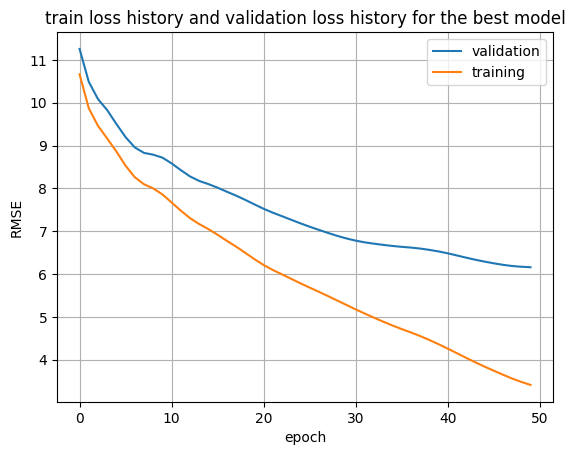

In [152]:
# TODO: Plot training and validation loss curves for the selected/best model.
plt.plot(range(best_stopped_epoch+1), best_val_loss, label="validation")
plt.plot(range(best_stopped_epoch+1), best_train_loss, label="training")

plt.grid()
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.title("train loss history and validation loss history for the best model")
plt.legend()
plt.show()

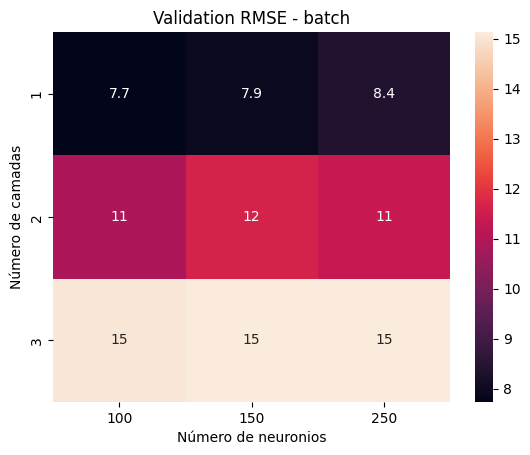

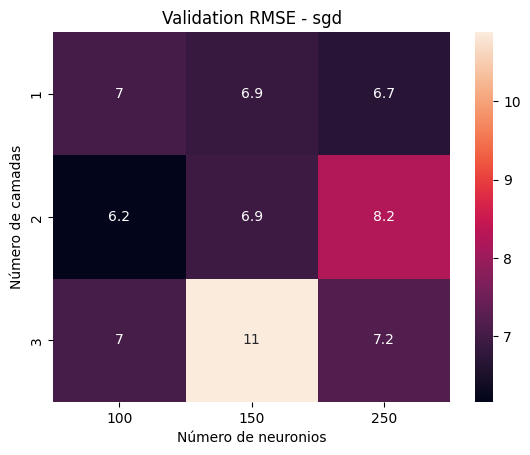

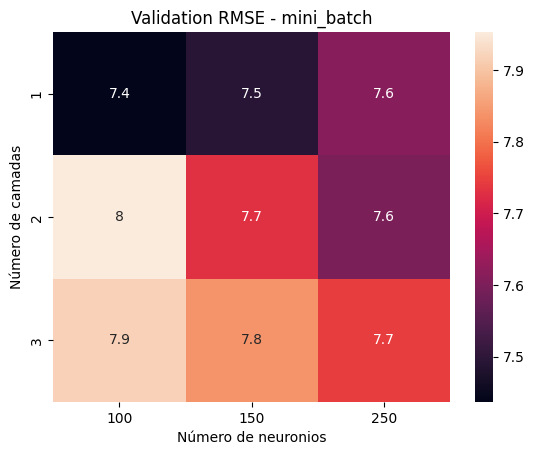

In [188]:
# TODO: Produce one validation RMSE heatmap per update method.
# Rows: number of hidden layers.
# Columns: neurons per hidden layer.
# Values: validation RMSE.

rr = regression_results

for i, x in enumerate(regression_update_methods):
    heatmap_data = rr[rr["update_method"] == x].pivot(
    index="hidden_layers",
    columns="neurons_per_layer",
    values="validation_rmse"
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
    )

    plt.title(f"Validation RMSE - {x}")
    plt.xlabel("Número de neuronios")
    plt.ylabel("Número de camadas")
    plt.show()


In [ ]:
# TODO: Select the final NumPy regression model using validation RMSE only.
# Then evaluate that selected model on the test set with RMSE.

# Expected variable names for the TensorFlow baseline cell:
# best_hidden_layers = ...
# best_neurons = ...
# best_regression_test_rmse = ...
# best_regression_validation_rmse = ...

raise NotImplementedError


## Scratch Linear Regression Baseline

Use your own linear regression implementation from previous labs or courseworks. Train it on the same training set and evaluate it on the same test set.


In [ ]:
class ScratchLinearRegression:
    def fit(self, X, y, epochs=5000, learning_rate=0.01):
        # TODO: paste/adapt your previous linear regression implementation.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predictions.
        raise NotImplementedError

# TODO: train and evaluate your scratch linear regression baseline.

raise NotImplementedError


## TensorFlow Regression Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `best_hidden_layers`, and `best_neurons`.


In [ ]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_hidden_layers" not in globals() or "best_neurons" not in globals():
    raise NameError("Define best_hidden_layers and best_neurons from your validation search before running this cell.")

regression_patience = globals().get("regression_patience", 10)
regression_epochs = globals().get("regression_epochs", 50)
regression_learning_rate = globals().get("regression_learning_rate", 0.01)

tf_regression_model = tf.keras.Sequential()
tf_regression_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for _ in range(int(best_hidden_layers)):
    tf_regression_model.add(tf.keras.layers.Dense(int(best_neurons), activation="sigmoid"))
tf_regression_model.add(tf.keras.layers.Dense(1, activation="linear"))

tf_regression_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=regression_learning_rate),
    loss="mse",
)

tf_regression_history = tf_regression_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=regression_epochs,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=regression_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_regression_val_predictions = tf_regression_model.predict(X_val, verbose=0)
tf_regression_test_predictions = tf_regression_model.predict(X_test, verbose=0)

tf_regression_results = pd.DataFrame([
    {
        "model": "TensorFlow regression baseline",
        "hidden_layers": int(best_hidden_layers),
        "neurons_per_layer": int(best_neurons),
        "validation_rmse": float(np.sqrt(np.mean((y_val - tf_regression_val_predictions) ** 2))),
        "test_rmse": float(np.sqrt(np.mean((y_test - tf_regression_test_predictions) ** 2))),
        "epochs_trained": len(tf_regression_history.history["loss"]),
    }
])

display(tf_regression_results)


In [ ]:
# TODO: Build the final regression comparison table.
# Include at least:
# - your NumPy NN
# - your scratch linear regression
# - the TensorFlow baseline above

raise NotImplementedError


# Part 2 - Multiclass Classification With Neural Networks (50%)

## Dataset

Use `dry_bean_database.csv`. Each row is one bean described by 16 numerical features. The target column is `Class`, with 7 mutually exclusive classes.

Required preprocessing:

1. Load the dataset.
2. Remove duplicated rows.
3. Convert numeric feature columns when needed. Some copies may store decimal values as strings with comma separators.
4. Encode `Class` as a multiclass target.
5. Split into training, validation, and test sets using a 70:15:15 ratio. Use stratification.
6. Standardize features manually using only training-set statistics.


In [ ]:
dry_beans = pd.read_csv("dry_bean_database.csv", decimal=",")
display(dry_beans.head())
display(dry_beans.describe(include="all"))


In [ ]:
# TODO: Classification preprocessing.
# - Drop duplicate rows.
# - Convert all feature columns to float.
# - Encode Class as integers and one-hot vectors.

# Expected variable names:
# class_names = [...]
# X = ...
# class_labels = ...
# y = ...  # one-hot encoded target

raise NotImplementedError


In [ ]:
# TODO: Split into train/validation/test using a 70:15:15 ratio with stratification.
# TODO: Standardize X_train, X_val, and X_test using only training-set statistics.

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test
# labels_train, labels_val, labels_test

raise NotImplementedError


## NumPy Multiclass Neural Network

Implement a fully connected multiclass classifier using NumPy.

Requirements:

- The architecture must accept a list of hidden-layer sizes, for example `[64, 128, 256]`.
- Use sigmoid activation functions in hidden layers.
- Use softmax in the output layer.
- Use multiclass cross-entropy loss.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support batch GD, SGD, and mini-batch GD.
- Use early stopping.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `1000` epochs.


In [ ]:
class NeuralNetworkMulticlassClassifier:
    def __init__(self, input_size, hidden_layers, output_size):
        # TODO: initialize weights and biases for the architecture list.
        raise NotImplementedError

    def forward(self, X):
        # TODO: implement sigmoid hidden layers and softmax output.
        raise NotImplementedError

    def backward(self, activations, y_true):
        # TODO: implement backpropagation for softmax + cross-entropy.
        raise NotImplementedError

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=1000,
        learning_rate=0.01,
        update_method="mini_batch",
        batch_size=256,
        patience=50,
    ):
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        raise NotImplementedError

    def predict_proba(self, X):
        # TODO: return class probabilities.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predicted class indices.
        raise NotImplementedError


## Classification Hyperparameter Tuning

Choose 3 hidden-layer configurations. The number of neurons does not need to be the same in every layer for this part.

For each update method, train the 3 architectures and record the validation loss. This gives 9 validation results.


In [ ]:
classification_layer_configs = [
    [64],
    [128, 64],
    [128, 128, 64],
]
classification_update_methods = ["batch", "sgd", "mini_batch"]
classification_learning_rate = 0.01
classification_epochs = 1000
classification_patience = 50

# TODO: train every architecture/update-method combination.
# Store at least: update_method, architecture, validation_loss, best_epoch, stopped_epoch.

# classification_results = pd.DataFrame(...)
# display(classification_results.sort_values("validation_loss"))

raise NotImplementedError


In [ ]:
# TODO: Plot training and validation loss curves for the selected/best classifier.

raise NotImplementedError


In [ ]:
# TODO: Produce one validation-loss heatmap per update method.
# Use architecture labels on the columns.

raise NotImplementedError


In [ ]:
# TODO: Select the final NumPy classifier using validation loss only.
# Then evaluate it on the test set with AUROC, precision, F1, and accuracy.

# Expected variable name for the TensorFlow baseline cell:
# best_classification_layers = ...

raise NotImplementedError


## Scratch Logistic Regression Baseline

Use your own logistic regression implementation from previous labs or courseworks. For this multiclass dataset, you may implement one-vs-rest logistic regression or softmax regression.


In [ ]:
class ScratchLogisticRegression:
    def fit(self, X, y, epochs=1000, learning_rate=0.01):
        # TODO: paste/adapt your previous logistic regression implementation.
        raise NotImplementedError

    def predict_proba(self, X):
        # TODO: return class probabilities.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predicted class indices.
        raise NotImplementedError

# TODO: train and evaluate your scratch logistic regression baseline.

raise NotImplementedError


## TensorFlow Classification Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `class_names`, and `best_classification_layers`.


In [ ]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_classification_layers" not in globals():
    raise NameError("Define best_classification_layers from your validation search before running this cell.")

classification_patience = globals().get("classification_patience", 50)
classification_epochs = globals().get("classification_epochs", 1000)
classification_learning_rate = globals().get("classification_learning_rate", 0.01)

tf_classification_model = tf.keras.Sequential()
tf_classification_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for units in best_classification_layers:
    tf_classification_model.add(tf.keras.layers.Dense(int(units), activation="sigmoid"))
tf_classification_model.add(tf.keras.layers.Dense(y_train.shape[1], activation="softmax"))

tf_classification_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=classification_learning_rate),
    loss="categorical_crossentropy",
)

tf_classification_history = tf_classification_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=classification_epochs,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=classification_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_classification_probabilities = tf_classification_model.predict(X_test, verbose=0)
tf_classification_predictions = np.argmax(tf_classification_probabilities, axis=1)
tf_true_labels = np.argmax(y_test, axis=1)

tf_precision, tf_recall, tf_f1, _ = precision_recall_fscore_support(
    tf_true_labels,
    tf_classification_predictions,
    average="macro",
    zero_division=0,
)

tf_classification_results = pd.DataFrame([
    {
        "model": "TensorFlow classification baseline",
        "architecture": str(list(best_classification_layers)),
        "test_macro_ovr_auroc": roc_auc_score(y_test, tf_classification_probabilities, average="macro"),
        "test_accuracy": accuracy_score(tf_true_labels, tf_classification_predictions),
        "test_macro_precision": tf_precision,
        "test_macro_recall": tf_recall,
        "test_macro_f1": tf_f1,
        "epochs_trained": len(tf_classification_history.history["loss"]),
    }
])

display(tf_classification_results)


In [ ]:
# TODO: Build the final classification comparison table and barplots.
# Include at least:
# - your NumPy NN
# - your scratch logistic regression
# - the TensorFlow baseline above

raise NotImplementedError
